Matias Herklotz (PECE/USP) -- 2025

# Tarefa: Linguística Forense

Seu grupo de especialistas em PLN foi chamado para periciar um texto de autor incógnito. Há três elementos suspeitos de ser o autor da obra. Todos negam veementemente a autoria. São eles:

* Machado de Assis, autor de "Dom Casmurro"
* José de Alencar, autor de "O Guarani"
* Joaquim Nabuco, autor de "O Abolicionismo"

Você tem à disposição esses livros para comparar com o livro apócrifo.

Em suas análises, use alguns dos recursos comuns da Linguística Forense:

* Análise das divisões de período (para simplificar: tamanho das sentenças);
* Comparação das colocações adverbiais, em especial os modais (etiqueta de dependência: "advmod") e as conjunções subordinativas ("que" e "se"; etiqueta: "sconj").

Ao final, responda: quem é o autor do livro apócrifo?

In [86]:
import nltk
import spacy
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
from matplotlib import pyplot as plt
nltk.download('punkt_tab')

nlp = spacy.load('pt_core_news_sm')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mathe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
def ler(nome_arquivo) -> str:
    with open(nome_arquivo, 'r', encoding='utf-8') as arquivo:
        return arquivo.read()


def tokenizar(txt: str) -> list:
    return word_tokenize(txt, language='portuguese')


def tokenizar_sentencas(txt: str) -> list:
    txt = txt.replace('\n', ' ')
    return sent_tokenize(txt, language='portuguese')


def limpar(lista: list) -> list:
    return [i.lower() for i in lista if i.isalpha()]


def contar_pos(txt: str) -> dict:
    doc = nlp(txt)
    return {
        "N_Advs": sum(1 for t in doc if t.pos_ == "ADV"),      
        "N_Adjs": sum(1 for t in doc if t.pos_ == "ADJ"),     
        "N_Verbs": sum(1 for t in doc if t.pos_ == "VERB"),    
        "N_CConj": sum(1 for t in doc if t.pos_ == "CCONJ"),  
        "N_SConj": sum(1 for t in doc if t.pos_ == "SCONJ"),  
        "N_Pron": sum(1 for t in doc if t.pos_ == "PRON"),  
    }


def textos_df(arq: str) -> pd.DataFrame:
    txt = ler(arq)
    sentencas = tokenizar_sentencas(txt)
    df_obra = pd.DataFrame({'Sentencas': sentencas})
    df_obra['TamSentencas'] = df_obra['Sentencas'].str.len() 
    # df_obra['ListaPalavras'] = df_obra['Sentencas'].apply(lambda x: tokenizar(x))
    df_obra['NumPalavras'] = df_obra['Sentencas'].apply(lambda x: len(tokenizar(x)))
    
    pos_counts_df = df_obra["Sentencas"].apply(contar_pos).apply(pd.Series).fillna(0)

    df = pd.concat([df_obra, pos_counts_df], axis=1)
    
    return df



In [153]:
df_g = textos_df('Guarani.txt')
df_g['Autor'] = 'José de Alencar'

df_dc = textos_df('DomCasmurro.txt')
df_dc['Autor'] = 'Machado de Assis'

df_a = textos_df('Abolicionismo.txt')
df_a['Autor'] = 'Joaquim Nabuco'

df_d = textos_df('LivroApócrifo.txt')
df_d['Autor'] = '???'


In [154]:
df = pd.concat([df_g, df_dc, df_a, df_d], ignore_index=True)
df.head()


,Sentencas,TamSentencas,NumPalavras,N_Advs,N_Adjs,N_Verbs,N_CConj,N_SConj,N_Pron,Autor
0,"O Guarani, de José de Alencar Fonte: ALENCAR, ...",54,14,0,0,0,0,0,0,José de Alencar
1,O guarani.,10,3,0,1,0,0,0,0,José de Alencar
2,"20a ed., São Paulo: Ática, 1996 (Bom Livro).",44,14,0,1,0,0,0,0,José de Alencar
3,Texto proveniente de: A Biblioteca Virtual do ...,196,32,1,2,0,0,0,0,José de Alencar
4,Este material pode ser redistribuído livrement...,120,21,3,0,4,1,3,0,José de Alencar


In [156]:
df_grouped = df.groupby("Autor").sum()
df_grouped = df_grouped.drop(['Sentencas'], axis=1)
df_grouped.head()


,TamSentencas,NumPalavras,N_Advs,N_Adjs,N_Verbs,N_CConj,N_SConj,N_Pron
Autor,,,,,,,,
???,215974,43107,1467,2060,5140,1216,1090,1762
Joaquim Nabuco,387521,72724,3769,4376,7336,2494,2103,4038
José de Alencar,617918,124634,5551,5504,17652,4268,3537,7588
Machado de Assis,395492,83161,5330,3680,11562,3242,3101,4727


In [ ]:
df_grouped["Advérbios"] = (df_grouped["N_Advs"] / df_grouped["NumPalavras"]) * 100
df_grouped["Adjetivos"] = (df_grouped["N_Adjs"] / df_grouped["NumPalavras"]) * 100
df_grouped["Verbos"] = (df_grouped["N_Verbs"] / df_grouped["NumPalavras"]) * 100
df_grouped["Conjunções Coordenativas"] = (df_grouped["N_CConj"] / df_grouped["NumPalavras"]) * 100
df_grouped["Conjunções Subordinativas"] = (df_grouped["N_SConj"] / df_grouped["NumPalavras"]) * 100
df_grouped["Pronomes"] = (df_grouped["N_Pron"] / df_grouped["NumPalavras"]) * 100


In [158]:
df_grouped.head()


,TamSentencas,NumPalavras,N_Advs,N_Adjs,N_Verbs,N_CConj,N_SConj,N_Pron,Advérbios,Adjetivos,Verbos,Conjunções Coordenativas,Conjunções Subordinativas,Pronomes
Autor,,,,,,,,,,,,,,
???,215974,43107,1467,2060,5140,1216,1090,1762,3.403160,4.778806,11.923817,2.820888,2.528592,4.087503
Joaquim Nabuco,387521,72724,3769,4376,7336,2494,2103,4038,5.182608,6.017271,10.087454,3.429404,2.891755,5.552500
José de Alencar,617918,124634,5551,5504,17652,4268,3537,7588,4.453841,4.416130,14.163069,3.424427,2.837909,6.088226
Machado de Assis,395492,83161,5330,3680,11562,3242,3101,4727,6.409254,4.425151,13.903152,3.898462,3.728911,5.684155


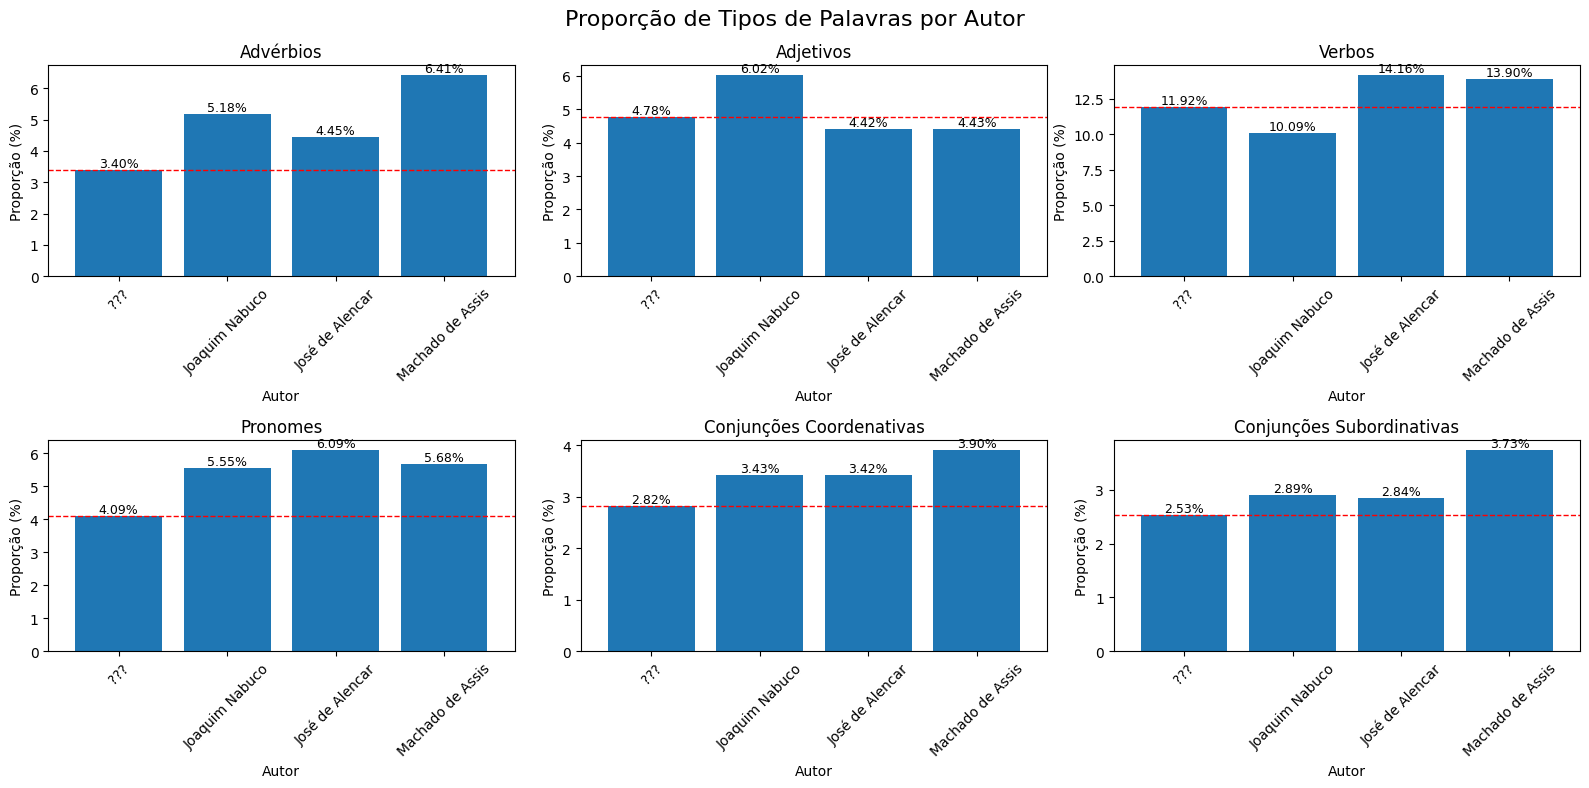

In [160]:
cols_proporcao = [
    "Advérbios", 
    "Adjetivos", 
    "Verbos", 
    "Pronomes", 
    "Conjunções Coordenativas", 
    "Conjunções Subordinativas", 
    "Interjeições"
]


import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))
fig.suptitle("Proporção de Tipos de Palavras por Autor", fontsize=16)

axes = axes.flatten()

for ax, col in zip(axes, cols_proporcao):
    df_grouped[col].plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(col)
    ax.set_xlabel("Autor")
    ax.set_ylabel("Proporção (%)")
    ax.tick_params(axis='x', rotation=45)

    for p, autor in zip(ax.patches, df_grouped.index):
        altura = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2, altura, f"{altura:.2f}%", ha='center', va='bottom', fontsize=9)

        if autor == "???":
            ax.axhline(y=altura, color='red', linestyle='dashed', linewidth=1)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()



## Analise

- Advérbios: texto esta mais alinhado com Alencar

- Adjetivos: texto esta menos alinhado com Nabuco

- Verbos: Inconclusivo

- Pronomes: Parece estar menos alinhado com Alencar, mas tambem distante do restante

- Conjuncoes: Ambas as conjuncoes mostram que Machado esta mais distante.


Por exclusao a analise mostra uma maior proximidade com Alencar


In [162]:
df_sen = df[['Autor','TamSentencas']].groupby("Autor").mean()
df_sen.head()


,TamSentencas
Autor,
???,111.441692
Joaquim Nabuco,210.380565
José de Alencar,106.943233
Machado de Assis,92.773164


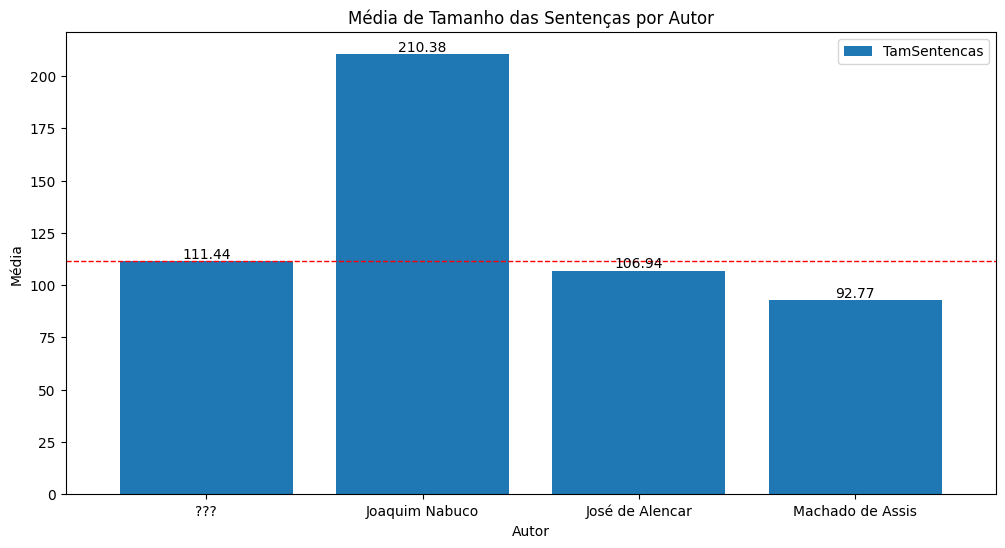

In [139]:
ax = df_sen.plot(kind="bar", figsize=(12, 6), width=0.8)

plt.title("Média de Tamanho das Sentenças por Autor")
plt.xlabel("Autor")
plt.ylabel("Média")
plt.xticks(rotation=0)

for p, autor in zip(ax.patches, df_sen.index):
    altura = p.get_height()
    plt.text(p.get_x() + p.get_width() / 2, altura, f"{altura:.2f}", ha='center', va='bottom', fontsize=10)

    if autor == "???":
        ax.axhline(y=altura, color='red', linestyle='dashed', linewidth=1)

plt.show()


## Analise Final

Ao analisar a proporção de tipos de palavra por autor podemos ver que Machado de Assis é o mais deslocado dos 3, principalmente quando observamos os Advérbios e as conjunções.

Ficamos entre Alencar e Nabuco, com uma tendencia maior ao Alencar.

Porém ao ver a media de palavras por sentença, podemos ver que Joaquim Nabuco é praticamente excluído, restando apenas o Alencar.

Podemos concluir então que Alencar é o Autor da obra Livro Apócrifo.